<a href="https://colab.research.google.com/github/mikecrv2019-bit/MAESTRIA-IA/blob/main/MAI540_Modulo4_Tarea_4.1/App_Diagnostico_Biopsias_Mama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# App de Diagnóstico Asistido — Clasificación de Biopsias de Mama

**MAI 540 — Machine Learning | Módulo 3**

Esta aplicación estima, a partir de mediciones tomadas de una biopsia por imagen, si un tumor es **maligno** o **benigno**. La idea es que el modelo ayude a priorizar qué casos revisa primero un especialista — la decisión final siempre es humana.

Dataset: *Wisconsin Breast Cancer* (incluido en `scikit-learn`), usado aquí con fines educativos.

---

**Esta aplicación no la escribiste tú.** Fue entregada por otra persona del equipo y necesita salir a producción esta semana. Antes de tocar una sola línea, tu trabajo es entenderla: qué hace cada función, cómo fluyen los datos de una celda a la siguiente, y qué pasa cuando la ejecutas de principio a fin.

Ejecuta todo el notebook, en orden, tal como está.

El código no tiene errores de sintaxis: corre sin problema hasta que la lógica falla. Los defectos son de comportamiento, no de escritura — no pierdas tiempo buscando un paréntesis o una coma fuera de lugar.

## Cómo trabajar con Claude Code en este ejercicio

Ya llevas dos módulos usando Claude Code — no arranques con instrucciones vagas como si fuera la primera semana. Aplica lo mismo que ya usaste en la Tarea 2.1 con tu propio dataset:

1. **Pide que lea antes de que toque nada.** Que te explique qué hace cada función y cómo fluyen los datos entre celdas, antes de autorizar un cambio.
2. **Formula tú la hipótesis, no se la pidas hecha.** Dile qué crees que está pasando y pídele que lo verifique — no preguntes directamente "¿por qué falla esto?".
3. **Verifica lo que decide por su cuenta.** Igual que revisaste tu propia columna prohibida en la Tarea 2.1, revisa aquí cada columna que el modelo usa: ¿existiría en el momento real de predecir?
4. **La métrica va antes que el cambio.** `diagnostico` está desbalanceado. No aceptes una corrección solo porque el número subió; compara antes/después sobre la misma partición.

Nada nuevo en *cómo* usar la herramienta. Lo nuevo esta semana es *sobre qué* la usas: este código no lo escribiste tú, pero ayudarás a resolver por qué no funciona.

**Nota de refactorizacion (revisada):** en una version anterior este notebook importaba las funciones desde `app.py` (`from app import ...`), para no duplicar logica con `test_app.py`. Eso rompe al abrir el notebook en Google Colab: Colab corre en una maquina virtual nueva que no tiene `app.py` (ni ningun otro archivo del repositorio), asi que la importacion falla con `ModuleNotFoundError: No module named 'app'` -- error real, reproducido al abrir este archivo en Colab.

Por eso el notebook vuelve a definir las funciones directamente en sus celdas (igual que el original), para poder ejecutarse de punta a punta sin depender de ningun archivo adjunto. `app.py` se mantiene con la misma logica, ya que es lo que usan las pruebas automatizadas de `test_app.py` (pytest no depende del notebook). Si se corrige algo del pipeline, hay que aplicarlo en los dos lugares -- ese es el costo de que el notebook sea autocontenido para Colab.

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42

# Columna identificada como fuga de informacion (ver INFORME_TAREA_3_1.md,
# seccion 2): es 100% determinista respecto a `diagnostico` porque las
# sesiones de tratamiento solo se programan DESPUES de saber que el tumor
# es maligno.
COLUMNA_FUGA = 'sesiones_tratamiento_programadas'

COLUMNAS_PREDICTORAS = [
    'mean texture', 'mean smoothness', 'mean symmetry', 'mean fractal dimension',
    'texture error', 'smoothness error', 'symmetry error',
    'variabilidad_por_biopsia', 'num_biopsias_previas',
]


def cargar_datos(random_state=RANDOM_STATE):
    """Carga el dataset de biopsias y agrega las columnas clinicas complementarias."""
    rng = np.random.RandomState(random_state)
    data = load_breast_cancer(as_frame=True)
    df = data.frame.copy()
    df['diagnostico'] = data.target  # 0 = maligno, 1 = benigno
    n = len(df)

    df['num_biopsias_previas'] = rng.randint(0, 4, size=n)
    df['sesiones_tratamiento_programadas'] = np.where(
        df['diagnostico'] == 0,
        rng.randint(3, 9, size=n),
        0,
    )
    return df


def explorar_datos(df):
    """Imprime un resumen rapido del dataset antes de entrenar nada."""
    print(f"Filas: {len(df)}  |  Columnas: {df.shape[1]}")
    print()
    print("Distribucion de diagnostico (0 = maligno, 1 = benigno):")
    print(df['diagnostico'].value_counts(normalize=True).round(3))
    print()
    print("Valores nulos por columna (solo columnas con al menos 1):")
    nulos = df.isna().sum()
    print(nulos[nulos > 0] if nulos.any() else "Ninguno")


def validar_datos(df, columnas, detener=True):
    """Revisa que las columnas indicadas no tengan nulos ni valores infinitos.

    detener=True (por defecto) lanza ValueError si encuentra un problema,
    para que un dato corrupto nunca llegue silenciosamente a entrenar un
    modelo. detener=False solo imprime un aviso y deja seguir.
    """
    problemas = {}
    for col in columnas:
        n_nulos = df[col].isna().sum()
        n_infinitos = np.isinf(df[col]).sum() if np.issubdtype(df[col].dtype, np.number) else 0
        if n_nulos or n_infinitos:
            problemas[col] = {'nulos': int(n_nulos), 'infinitos': int(n_infinitos)}

    if problemas:
        detalle = "\n".join(
            f"  - {c}: {d['nulos']} nulos, {d['infinitos']} infinitos"
            for c, d in problemas.items()
        )
        mensaje = f"Validacion fallida en {len(problemas)} columna(s):\n{detalle}"
        if detener:
            raise ValueError(mensaje)
        print("AVISO:", mensaje)
    else:
        print(f"Validacion OK: {len(columnas)} columnas sin nulos ni infinitos.")

    return problemas


def construir_caracteristicas(df):
    """Agrega una metrica derivada de variabilidad de textura por biopsia previa."""
    df = df.copy()
    df['variabilidad_por_biopsia'] = df['mean texture'] / (df['num_biopsias_previas'] + 1)
    return df


def entrenar_modelo(df, usar_class_weight=False, columnas_predictoras=None, validar=True):
    """Entrena un clasificador de regresion logistica y devuelve el modelo y sus metricas."""
    columnas = columnas_predictoras if columnas_predictoras is not None else COLUMNAS_PREDICTORAS

    if validar:
        validar_datos(df, columnas, detener=True)

    X = df[columnas]
    y = df['diagnostico']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )

    kwargs = {'max_iter': 5000}
    if usar_class_weight:
        kwargs['class_weight'] = 'balanced'

    modelo = LogisticRegression(**kwargs)
    modelo.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_test = accuracy_score(y_test, modelo.predict(X_test))
    return modelo, acc_train, acc_test


def guardar_modelo(modelo, ruta="modelo_biopsias.joblib"):
    """Serializa el modelo entrenado para que el servicio de inferencia lo cargue."""
    joblib.dump(modelo, ruta)
    print(f"Modelo guardado en: {ruta}")


def predecir_caso(modelo, caso: dict):
    """Predice el diagnostico para una paciente nueva a partir de un diccionario de mediciones."""
    entrada = pd.DataFrame([caso])[COLUMNAS_PREDICTORAS]
    pred = modelo.predict(entrada)[0]
    return 'benigno' if pred == 1 else 'maligno'


## 1. Carga de datos

Cargamos el dataset base y lo enriquecemos con dos columnas que el equipo clínico pidió agregar:

- `num_biopsias_previas`: cuántas biopsias se le habían hecho antes a la paciente.
- `sesiones_tratamiento_programadas`: cuántas sesiones de tratamiento tiene ya programadas la paciente.

In [2]:
df = cargar_datos()
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico,num_biopsias_previas,sesiones_tratamiento_programadas
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0,0,2,8
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0,0,3,5
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0,0,0,3
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0,0,2,4
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0,0,2,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,0,3,4
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,0,1,6
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,0,1,8
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,0,3,4


## 2. Exploración inicial

Antes de modificar nada, conviene entender qué llegó: cuántos casos hay, cómo se distribuye el diagnóstico, y si hay datos faltantes.

In [3]:
explorar_datos(df)

Filas: 569  |  Columnas: 34

Distribucion de diagnostico (0 = maligno, 1 = benigno):
diagnostico
1    0.627
0    0.373
Name: proportion, dtype: float64

Valores nulos por columna (solo columnas con al menos 1):
Ninguno


### Gráficas de exploración

Dos vistas rápidas: cómo se distribuye la clase objetivo, y cómo se correlaciona cada columna numérica con el diagnóstico.

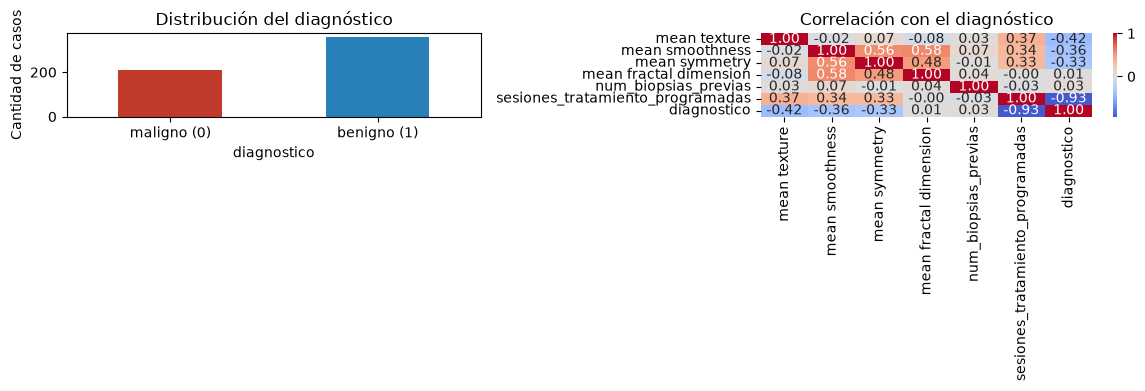

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['diagnostico'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#c0392b', '#2980b9']
)
axes[0].set_xticklabels(['maligno (0)', 'benigno (1)'], rotation=0)
axes[0].set_title('Distribución del diagnóstico')
axes[0].set_ylabel('Cantidad de casos')

columnas_para_correlacion = [
    'mean texture', 'mean smoothness', 'mean symmetry', 'mean fractal dimension',
    'num_biopsias_previas', 'sesiones_tratamiento_programadas', 'diagnostico',
]
corr = df[columnas_para_correlacion].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlación con el diagnóstico')

plt.tight_layout()
plt.show()

## 3. Validación de calidad de datos

Un chequeo simple antes de entrenar: que no haya valores infinitos ni nulos colándose en las columnas numéricas.

In [5]:
# Diagnostico del ValueError original: dos hipotesis sobre que funcion lo introduce.
# H1: cargar_datos() genera el valor no finito.
# H2: construir_caracteristicas() lo genera, al dividir por num_biopsias_previas == 0.
# Evidencia completa y hallazgos en INFORME_TAREA_3_1.md (seccion "Depuracion").

def _construir_caracteristicas_version_original(df):
    """Version SIN corregir (la que trajo el equipo), solo para reproducir el diagnostico."""
    df = df.copy()
    df['variabilidad_por_biopsia'] = df['mean texture'] / df['num_biopsias_previas']
    return df

df_crudo = cargar_datos()
problemas_h1 = validar_datos(df_crudo, ['mean texture', 'num_biopsias_previas'], detener=False)
print("H1 (cargar_datos):", "sin problemas -> DESCARTADA" if not problemas_h1 else problemas_h1)

print()
df_bug = _construir_caracteristicas_version_original(df_crudo)
problemas_h2 = validar_datos(df_bug, ['variabilidad_por_biopsia'], detener=False)
print("H2 (construir_caracteristicas, version original):", problemas_h2)
n_ceros = (df_bug['num_biopsias_previas'] == 0).sum()
print(f"Filas con num_biopsias_previas == 0: {n_ceros} -> coinciden con las filas 'infinitos' de arriba: CONFIRMADA")

Validacion OK: 2 columnas sin nulos ni infinitos.
H1 (cargar_datos): sin problemas -> DESCARTADA

AVISO: Validacion fallida en 1 columna(s):
  - variabilidad_por_biopsia: 0 nulos, 135 infinitos
H2 (construir_caracteristicas, version original): {'variabilidad_por_biopsia': {'nulos': 0, 'infinitos': 135}}
Filas con num_biopsias_previas == 0: 135 -> coinciden con las filas 'infinitos' de arriba: CONFIRMADA


## 4. Ingeniería de características

A partir de la textura promedio y del número de biopsias previas, construimos un indicador de variabilidad por biopsia — mientras más biopsias previas tenga la paciente, más se "diluye" la variabilidad reportada.

In [6]:
df_features = construir_caracteristicas(df)
validar_datos(df_features, ['variabilidad_por_biopsia'])
df_features[['mean texture', 'num_biopsias_previas', 'variabilidad_por_biopsia']].head(10)

Validacion OK: 1 columnas sin nulos ni infinitos.


,mean texture,num_biopsias_previas,variabilidad_por_biopsia
0,10.38,2,3.460000
1,17.77,3,4.442500
2,21.25,0,21.250000
3,20.38,2,6.793333
4,14.34,2,4.780000
5,15.70,3,3.925000
6,19.98,0,19.980000
7,20.83,0,20.830000
8,21.82,2,7.273333
9,24.04,1,12.020000


### Distribución de la característica nueva

Así se ve la variable recién construida. Vale la pena revisar si su forma tiene sentido.

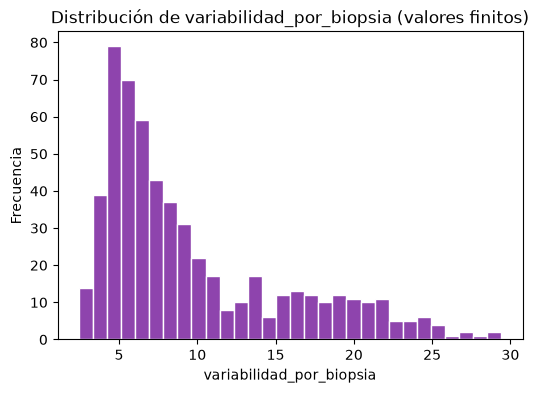

Valores no finitos (inf/NaN) en la columna: 0 de 569


In [7]:
valores_finitos = df_features['variabilidad_por_biopsia'].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(6, 4))
plt.hist(valores_finitos.dropna(), bins=30, color='#8e44ad', edgecolor='white')
plt.title('Distribución de variabilidad_por_biopsia (valores finitos)')
plt.xlabel('variabilidad_por_biopsia')
plt.ylabel('Frecuencia')
plt.show()

print(f"Valores no finitos (inf/NaN) en la columna: "
      f"{(~np.isfinite(df_features['variabilidad_por_biopsia'])).sum()} de {len(df_features)}")

## 5. Entrenamiento del modelo

Usamos regresión logística — el mismo clasificador que ya conoces — sobre un subconjunto de columnas clínicas y de imagen.

In [8]:
print("Columnas predictoras (ya corregidas):")
print(COLUMNAS_PREDICTORAS)
print()
print(f"Columna excluida por fuga de informacion: '{COLUMNA_FUGA}'")
print("(solo se conoce despues del diagnostico -> ver INFORME_TAREA_3_1.md, seccion 2)")

Columnas predictoras (ya corregidas):
['mean texture', 'mean smoothness', 'mean symmetry', 'mean fractal dimension', 'texture error', 'smoothness error', 'symmetry error', 'variabilidad_por_biopsia', 'num_biopsias_previas']

Columna excluida por fuga de informacion: 'sesiones_tratamiento_programadas'
(solo se conoce despues del diagnostico -> ver INFORME_TAREA_3_1.md, seccion 2)


## 6. Ejecutar el pipeline completo

Esto es lo que corre en producción: carga los datos, construye las características y entrena el modelo.

In [9]:
df_features = construir_caracteristicas(cargar_datos())
modelo, acc_train, acc_test = entrenar_modelo(df_features)
print(f"Accuracy en entrenamiento: {acc_train:.4f}")
print(f"Accuracy en prueba:        {acc_test:.4f}")

Validacion OK: 9 columnas sin nulos ni infinitos.


Accuracy en entrenamiento: 0.7324
Accuracy en prueba:        0.7343


### 6.1 Efecto de la fuga de informacion

`sesiones_tratamiento_programadas` es 100% determinista respecto a `diagnostico` (se programan sesiones de tratamiento *despues* de saber que el tumor es maligno). Se entrena el mismo modelo, sobre la misma particion train/test, con y sin esa columna, para medir cuanto 'optimismo' le agregaba al accuracy.

In [10]:
COLUMNAS_CON_FUGA = COLUMNAS_PREDICTORAS + [COLUMNA_FUGA]

_, acc_train_con, acc_test_con = entrenar_modelo(df_features, columnas_predictoras=COLUMNAS_CON_FUGA)
_, acc_train_sin, acc_test_sin = entrenar_modelo(df_features, columnas_predictoras=COLUMNAS_PREDICTORAS)

print(f"CON fuga  -> accuracy train: {acc_train_con:.4f}  |  accuracy test: {acc_test_con:.4f}")
print(f"SIN fuga  -> accuracy train: {acc_train_sin:.4f}  |  accuracy test: {acc_test_sin:.4f}")
print(f"Optimismo que introducia la fuga (accuracy de prueba): {acc_test_con - acc_test_sin:+.4f}")

Validacion OK: 10 columnas sin nulos ni infinitos.
Validacion OK: 9 columnas sin nulos ni infinitos.
CON fuga  -> accuracy train: 1.0000  |  accuracy test: 1.0000
SIN fuga  -> accuracy train: 0.7324  |  accuracy test: 0.7343
Optimismo que introducia la fuga (accuracy de prueba): +0.2657


### 6.2 Efecto del desbalance de clases

`diagnostico` esta desbalanceado (~63% benigno / 37% maligno). Se compara `entrenar_modelo(usar_class_weight=False)` contra `usar_class_weight=True`, ya sin la fuga, sobre la misma particion, y se mira tambien el *recall* por clase (no solo accuracy) porque en un diagnostico medico un falso negativo en 'maligno' pesa mucho mas que un falso positivo.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

_, _, acc_test_False = entrenar_modelo(df_features, usar_class_weight=False)
_, _, acc_test_True = entrenar_modelo(df_features, usar_class_weight=True)
print(f"usar_class_weight=False -> accuracy test: {acc_test_False:.4f}")
print(f"usar_class_weight=True  -> accuracy test: {acc_test_True:.4f}")

X = df_features[COLUMNAS_PREDICTORAS]
y = df_features['diagnostico']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

from sklearn.linear_model import LogisticRegression
for peso in (None, 'balanced'):
    kwargs = {'max_iter': 5000}
    if peso:
        kwargs['class_weight'] = peso
    m = LogisticRegression(**kwargs)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    print(f"\n--- class_weight={peso!r} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['maligno(0)', 'benigno(1)'], digits=4))

Validacion OK: 9 columnas sin nulos ni infinitos.
Validacion OK: 9 columnas sin nulos ni infinitos.
usar_class_weight=False -> accuracy test: 0.7343
usar_class_weight=True  -> accuracy test: 0.7343



--- class_weight=None ---
[[27 26]
 [12 78]]
              precision    recall  f1-score   support

  maligno(0)     0.6923    0.5094    0.5870        53
  benigno(1)     0.7500    0.8667    0.8041        90

    accuracy                         0.7343       143
   macro avg     0.7212    0.6881    0.6955       143
weighted avg     0.7286    0.7343    0.7236       143




--- class_weight='balanced' ---
[[36 17]
 [21 69]]
              precision    recall  f1-score   support

  maligno(0)     0.6316    0.6792    0.6545        53
  benigno(1)     0.8023    0.7667    0.7841        90

    accuracy                         0.7343       143
   macro avg     0.7170    0.7230    0.7193       143
weighted avg     0.7390    0.7343    0.7361       143



### 6.3 Evaluación de clasificación: matriz de confusión y métricas de la clase "maligno" (Tarea 4.1, punto 1)

Se evalúa el **modelo de producción** (`modelo`, entrenado en la sección 6: sin la columna con fuga y sin `class_weight`) sobre **la misma partición de prueba** que usa `entrenar_modelo()` (`test_size=0.25`, `random_state=RANDOM_STATE`, `stratify=y`).

**Cuidado con la codificación de la clase:** en este dataset `0 = maligno` y `1 = benigno`. Las funciones `precision_score`, `recall_score` y `f1_score` de scikit-learn usan por defecto `pos_label=1`, que aquí sería *benigno*. Por eso se pasa `pos_label=0` explícitamente, y además se recalculan las tres métricas a mano desde la matriz de confusión para comprobar que coinciden.

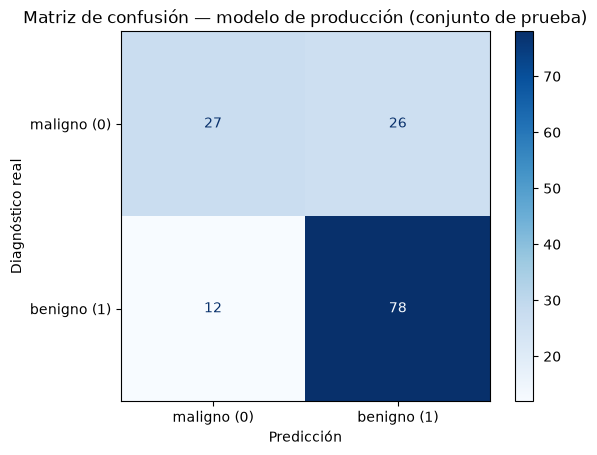

VP=27  FN=26  FP=12  VN=78  (total prueba = 143)
Precisión   (maligno): 0.6923  = VP/(VP+FP) = 27/39
Exhaustividad (maligno): 0.5094  = VP/(VP+FN) = 27/53
F1          (maligno): 0.5870
Accuracy global:       0.7343  <- no muestra que se escapan 26 de 53 tumores malignos
Verificación: métricas de sklearn (pos_label=0) == métricas calculadas a mano desde la matriz: OK
Validacion OK: 9 columnas sin nulos ni infinitos.


,Modelo,FN (malignos no detectados),FP (benignos marcados malignos),Precisión (maligno),Exhaustividad (maligno),F1 (maligno)
0,Producción (sin class_weight),26,12,0.6923,0.5094,0.5870
1,class_weight='balanced',17,21,0.6316,0.6792,0.6545


In [12]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

ETIQUETA_MALIGNO = 0  # 0 = maligno, 1 = benigno (ver cargar_datos)

X_eval = df_features[COLUMNAS_PREDICTORAS]
y_eval = df_features['diagnostico']
_, X_test_eval, _, y_test_eval = train_test_split(
    X_eval, y_eval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_eval
)
y_pred_eval = modelo.predict(X_test_eval)

# Filas = clase real, columnas = clase predicha; orden [maligno, benigno]
cm = confusion_matrix(y_test_eval, y_pred_eval, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=['maligno (0)', 'benigno (1)']).plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión — modelo de producción (conjunto de prueba)')
plt.xlabel('Predicción')
plt.ylabel('Diagnóstico real')
plt.show()

precision_m = precision_score(y_test_eval, y_pred_eval, pos_label=ETIQUETA_MALIGNO)
recall_m = recall_score(y_test_eval, y_pred_eval, pos_label=ETIQUETA_MALIGNO)
f1_m = f1_score(y_test_eval, y_pred_eval, pos_label=ETIQUETA_MALIGNO)

# Verificación cruzada: las mismas métricas calculadas a mano desde la matriz
vp = cm[0, 0]  # maligno real, predicho maligno   (verdadero positivo)
fn = cm[0, 1]  # maligno real, predicho benigno   (falso negativo: el error grave)
fp = cm[1, 0]  # benigno real, predicho maligno   (falso positivo)
vn = cm[1, 1]  # benigno real, predicho benigno   (verdadero negativo)
precision_manual = vp / (vp + fp)
recall_manual = vp / (vp + fn)
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)
assert np.isclose(precision_m, precision_manual)
assert np.isclose(recall_m, recall_manual)
assert np.isclose(f1_m, f1_manual)

print(f"VP={vp}  FN={fn}  FP={fp}  VN={vn}  (total prueba = {cm.sum()})")
print(f"Precisión   (maligno): {precision_m:.4f}  = VP/(VP+FP) = {vp}/{vp + fp}")
print(f"Exhaustividad (maligno): {recall_m:.4f}  = VP/(VP+FN) = {vp}/{vp + fn}")
print(f"F1          (maligno): {f1_m:.4f}")
print(f"Accuracy global:       {(vp + vn) / cm.sum():.4f}  <- no muestra que se escapan {fn} de {vp + fn} tumores malignos")
print("Verificación: métricas de sklearn (pos_label=0) == métricas calculadas a mano desde la matriz: OK")

# Misma evaluación para la variante con class_weight='balanced' (sección 6.2), para comparar el trade-off
modelo_balanceado, _, _ = entrenar_modelo(df_features, usar_class_weight=True)
y_pred_bal = modelo_balanceado.predict(X_test_eval)
resumen = pd.DataFrame({
    'Modelo': ['Producción (sin class_weight)', "class_weight='balanced'"],
    'FN (malignos no detectados)': [confusion_matrix(y_test_eval, p, labels=[0, 1])[0, 1] for p in (y_pred_eval, y_pred_bal)],
    'FP (benignos marcados malignos)': [confusion_matrix(y_test_eval, p, labels=[0, 1])[1, 0] for p in (y_pred_eval, y_pred_bal)],
    'Precisión (maligno)': [precision_score(y_test_eval, p, pos_label=0) for p in (y_pred_eval, y_pred_bal)],
    'Exhaustividad (maligno)': [recall_score(y_test_eval, p, pos_label=0) for p in (y_pred_eval, y_pred_bal)],
    'F1 (maligno)': [f1_score(y_test_eval, p, pos_label=0) for p in (y_pred_eval, y_pred_bal)],
}).round(4)
resumen

### 6.4 ¿Qué métrica es prioritaria en este contexto?

En esta aplicación la métrica prioritaria es la **exhaustividad (recall) de la clase "maligno"**, porque los dos tipos de error no cuestan lo mismo. Un **falso negativo** —un tumor maligno clasificado como benigno— hace que la paciente quede al final de la fila de revisión o, peor, que se descarte el caso, lo que retrasa el diagnóstico y el tratamiento en una enfermedad donde el tiempo cambia el pronóstico; es un error que puede ser irreversible. Un **falso positivo** —un tumor benigno marcado como maligno— cuesta una revisión adicional del patólogo, estudios complementarios y ansiedad para la paciente, pero se corrige en el paso siguiente del proceso clínico. Por eso lo que primero debe garantizar el modelo es no dejar escapar malignos, es decir, minimizar FN. La **precisión** queda como restricción secundaria (si es muy baja, los especialistas se saturan de falsas alarmas y dejan de confiar en la priorización) y el **F1** sirve para comparar modelos solo cuando la exhaustividad es aceptable, porque pondera por igual dos errores que aquí no pesan igual. Los resultados de la celda anterior muestran por qué el *accuracy* no basta: el modelo de producción tiene accuracy de 0.7343, pero su exhaustividad para "maligno" es de apenas **0.5094** (detecta 27 de 53 malignos y **deja escapar 26**), con precisión de 0.6923 y F1 de 0.5870. La variante con `class_weight='balanced'` sube la exhaustividad a **0.6792** (FN baja de 26 a 17) a cambio de más falsas alarmas (FP sube de 12 a 21, precisión 0.6316), y también mejora el F1 (0.6545); según el criterio de costo, ese intercambio conviene. Aun así, ninguno de los dos modelos es apto para uso clínico: perder uno de cada tres malignos sigue siendo inaceptable, y el siguiente paso sería mejorar las variables predictoras y ajustar el umbral de decisión para priorizar la exhaustividad, validándolo con validación cruzada y no sobre este único conjunto de prueba.

### Peso de cada variable en el modelo

En regresión logística, cada coeficiente indica cuánto empuja esa variable hacia "benigno" o hacia "maligno". Una variable con un peso muchísimo mayor que las demás merece una segunda mirada.

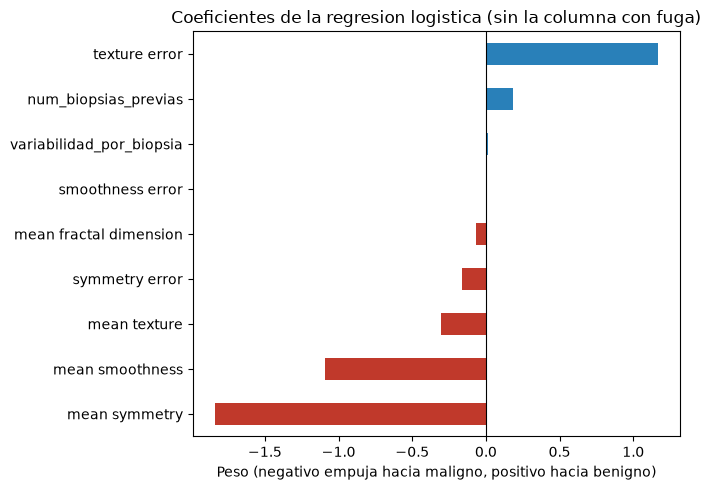

In [13]:
coeficientes = pd.Series(modelo.coef_[0], index=COLUMNAS_PREDICTORAS).sort_values()

plt.figure(figsize=(7, 5))
colores = ['#c0392b' if v < 0 else '#2980b9' for v in coeficientes]
coeficientes.plot(kind='barh', color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes de la regresion logistica (sin la columna con fuga)')
plt.xlabel('Peso (negativo empuja hacia maligno, positivo hacia benigno)')
plt.tight_layout()
plt.show()

## 7. Guardar el modelo entrenado

El equipo de infraestructura toma este archivo y lo despliega tal cual — así que necesita quedar en un estado entrenado y correcto.

In [14]:
guardar_modelo(modelo)

Modelo guardado en: modelo_biopsias.joblib


## 8. Predecir un caso nuevo

Así es como el equipo clínico piensa usar la app: le pasan las mediciones de una paciente nueva y el modelo devuelve una predicción.

In [15]:
def predecir_caso_ejemplo():
    caso_nuevo = {
        'mean texture': 18.2,
        'mean smoothness': 0.095,
        'mean symmetry': 0.18,
        'mean fractal dimension': 0.062,
        'texture error': 1.1,
        'smoothness error': 0.006,
        'symmetry error': 0.02,
        'variabilidad_por_biopsia': 18.2,
        'num_biopsias_previas': 1,
        # 'sesiones_tratamiento_programadas' ya NO se pide: en la realidad no
        # existe todavia cuando se predice (ver INFORME_TAREA_3_1.md, seccion 2).
    }
    return caso_nuevo

caso_nuevo = predecir_caso_ejemplo()
predecir_caso(modelo, caso_nuevo)

'benigno'